2.概述、线性代数和 NDArray

![2.1理论计算题](2.1理论计算题.jpg)

2.2编程题

In [2]:
import numpy as np

# 1. 创建 3×4 的标准正态分布随机矩阵 X
X = np.random.randn(3, 4)
print("1. 矩阵 X：")
print(X)

# 2. 创建 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n2. 矩阵 Y：")
print(Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("\n3. 矩阵 Z：")
print(Z)

# 4. 输出 Z 的第一行第二列元素，以及第 2 行所有元素

z_element = Z[0, 1]
z_row2 = Z[1, :]
print("\n4. Z 的第一行第二列元素：", z_element)
print("   Z 的第 2 行所有元素：", z_row2)

# 5. 计算 Z 的 Frobenius 范数
z_frobenius_norm = np.linalg.norm(Z, 'fro')
print("\n5. Z 的 Frobenius 范数：", z_frobenius_norm)

1. 矩阵 X：
[[-1.15068104  0.89101429  1.8715292   0.33213128]
 [ 1.1740903  -0.01644219 -0.84349527 -0.81399615]
 [ 1.11863379 -0.45925478  0.09400734 -1.22722316]]

2. 矩阵 Y：
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵 Z：
[[ 1.94399372  1.94399372]
 [-0.49984331 -0.49984331]
 [-0.47383681 -0.47383681]]

4. Z 的第一行第二列元素： 1.9439937217365888
   Z 的第 2 行所有元素： [-0.49984331 -0.49984331]

5. Z 的 Frobenius 范数： 2.9166680468653685


3.概率与统计

![3.1理论计算题](3.1理论计算题.jpg)

3.2编程题

中心极限定理模拟开始：
单次样本量 n = 10000，重复次数 m = 1000
第   1 次样本均值：0.499147
第   2 次样本均值：0.503927
第   3 次样本均值：0.498927
第   4 次样本均值：0.495100
第   5 次样本均值：0.495683
...
已完成 1000 次均值计算



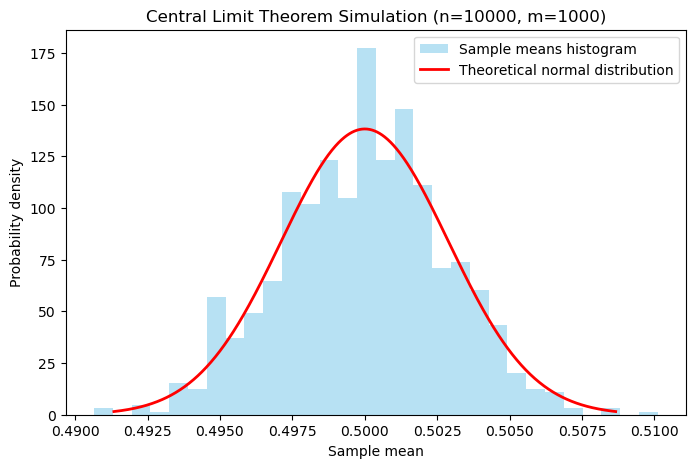

方差对比结果：
理论方差：0.00000833
实际方差：0.00000809
两者误差：0.00000024


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 题目参数
n = 10000  # 每次样本数量
m = 1000   # 重复次数

print("="*60)
print("中心极限定理模拟开始：")
print(f"单次样本量 n = {n}，重复次数 m = {m}")
print("="*60)

# 1. 模拟：生成均值
means = []
for i in range(m):
    samples = np.random.uniform(0, 1, size=n)
    sample_mean = np.mean(samples)
    means.append(sample_mean)
    
    # 可选：打印前5次均值，方便看过程（不想看可以注释掉）
    if i < 5:
        print(f"第 {i+1:3d} 次样本均值：{sample_mean:.6f}")

means = np.array(means)
print("...")
print(f"已完成 {m} 次均值计算\n")

# 2. 绘制直方图 + 理论正态曲线
plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', label='Sample means histogram')

# 理论正态分布参数
mu_theory = 0.5
sigma_theory = np.sqrt(1/12 / n)
x = np.linspace(mu_theory - 3*sigma_theory, mu_theory + 3*sigma_theory, 1000)
pdf = norm.pdf(x, loc=mu_theory, scale=sigma_theory)
plt.plot(x, pdf, 'r-', lw=2, label='Theoretical normal distribution')

plt.xlabel('Sample mean')
plt.ylabel('Probability density')
plt.legend()
plt.title(f'Central Limit Theorem Simulation (n={n}, m={m})')
plt.show()

# 3. 计算并输出方差对比
actual_variance = np.var(means, ddof=1)  # 无偏方差
theory_variance = sigma_theory ** 2

print("="*60)
print("方差对比结果：")
print(f"理论方差：{theory_variance:.8f}")
print(f"实际方差：{actual_variance:.8f}")
print(f"两者误差：{abs(theory_variance - actual_variance):.8f}")
print("="*60)

4.导数、反向传播和复杂度

![4.1理论计算题](4.1理论计算题.jpg)

In [6]:
import torch
# 1. 前向计算定义 + 2. 前向结果计算

def forward_pass(x, w1, w2):
    a = x * w1       # 第一步：乘法
    b = a + w2       # 第二步：加法
    L = b ** 2       # 第三步：平方损失
    return a, b, L

# 给定参数
x = 2
w1 = 1.5
w2 = 0.5

print("="*60)
print("【1-2 前向计算过程】")
a, b, L = forward_pass(x, w1, w2)
print(f"输入: x = {x}, w1 = {w1}, w2 = {w2}")
print(f"中间结果 a = x*w1 = {x} * {w1} = {a}")
print(f"中间结果 b = a + w2 = {a} + {w2} = {b}")
print(f"最终损失 L = b² = {b}² = {L}")
print("="*60)


# 3. 手动链式法则求梯度

print("\n【3 手动链式法则梯度计算】")
# 链式求导：dL/dw1 = dL/db * db/da * da/dw1
# dL/db = 2b
# db/da = 1
# da/dw1 = x
dL_db = 2 * b
db_da = 1
da_dw1 = x
dL_dw1 = dL_db * db_da * da_dw1

# 链式求导：dL/dw2 = dL/db * db/dw2
# db/dw2 = 1
db_dw2 = 1
dL_dw2 = dL_db * db_dw2

print(f"手动计算：dL/db = 2*b = 2*{b} = {dL_db}")
print(f"手动计算：dL/dw1 = dL/db * db/da * da/dw1 = {dL_db} * 1 * {x} = {dL_dw1}")
print(f"手动计算：dL/dw2 = dL/db * db/dw2 = {dL_db} * 1 = {dL_dw2}")


# PyTorch 自动微分验证

print("\n【PyTorch 自动微分验证】")
# 定义可求导的张量
x_t = torch.tensor(x, dtype=torch.float32)
w1_t = torch.tensor(w1, dtype=torch.float32, requires_grad=True)
w2_t = torch.tensor(w2, dtype=torch.float32, requires_grad=True)

# 前向传播
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"自动微分结果：dL/dw1 = {w1_t.grad.item()}")
print(f"自动微分结果：dL/dw2 = {w2_t.grad.item()}")

# 对比结果
print("\n" + "="*60)
print("结果对比：")
print(f"dL/dw1 手动 = {dL_dw1}，自动微分 = {w1_t.grad.item()}，是否一致：{abs(dL_dw1 - w1_t.grad.item()) < 1e-6}")
print(f"dL/dw2 手动 = {dL_dw2}，自动微分 = {w2_t.grad.item()}，是否一致：{abs(dL_dw2 - w2_t.grad.item()) < 1e-6}")
print("="*60)

【1-2 前向计算过程】
输入: x = 2, w1 = 1.5, w2 = 0.5
中间结果 a = x*w1 = 2 * 1.5 = 3.0
中间结果 b = a + w2 = 3.0 + 0.5 = 3.5
最终损失 L = b² = 3.5² = 12.25

【3 手动链式法则梯度计算】
手动计算：dL/db = 2*b = 2*3.5 = 7.0
手动计算：dL/dw1 = dL/db * db/da * da/dw1 = 7.0 * 1 * 2 = 14.0
手动计算：dL/dw2 = dL/db * db/dw2 = 7.0 * 1 = 7.0

【PyTorch 自动微分验证】
自动微分结果：dL/dw1 = 14.0
自动微分结果：dL/dw2 = 7.0

结果对比：
dL/dw1 手动 = 14.0，自动微分 = 14.0，是否一致：True
dL/dw2 手动 = 7.0，自动微分 = 7.0，是否一致：True


5.线性方法、基础优化和 softmax 回归

![5.1理论计算题](5.1理论计算题.jpg)

编程题

In [9]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


# 1. 加载数据集

print("="*60)
print("【1. 加载数据集】")
digits = load_digits()
X = digits.data  # 图像数据 (1797, 64)
y = digits.target # 标签 (1797,)
print(f"数据集大小: {X.shape[0]} 张图片，每张图片维度: {X.shape[1]}")
print(f"标签类别数: {len(np.unique(y))} (0-9)")

# 2. 数据预处理：展平（已完成）+ 标准化 + one-hot 编码

print("\n【2. 数据预处理】")
# 标准化（像素值缩放到0-1）
X = X / 16.0  # 原始像素范围0-16
print(f"标准化后，像素值范围: [{X.min()}, {X.max()}]")

# one-hot 编码标签
encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_onehot = encoder.fit_transform(y.reshape(-1, 1))
print(f"标签 one-hot 编码后形状: {y_onehot.shape}")

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)
print(f"训练集大小: {X_train.shape[0]}, 测试集大小: {X_test.shape[0]}")


# 3. 实现 softmax 函数和交叉熵损失

print("\n【3. 实现核心函数】")

def softmax(z):
    # 数值稳定版 softmax，防止溢出
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # 交叉熵损失，加小常数防止log(0)
    n_samples = y_true.shape[0]
    logp = - np.log(y_pred + 1e-9)
    loss = np.sum(y_true * logp) / n_samples
    return loss

# 测试 softmax 函数
test_z = np.array([[1, 2, 3], [1000, 1001, 1002]])
test_softmax = softmax(test_z)
print("测试 softmax 函数（输入含大数）：")
print(test_softmax)

# 初始化参数

n_features = X_train.shape[1]  # 64
n_classes = y_train.shape[1]   # 10
W = np.random.randn(n_features, n_classes) * 0.01  # 权重 (64,10)
b = np.zeros((1, n_classes))                       # 偏置 (1,10)
print(f"\n初始化参数：W 形状 {W.shape}, b 形状 {b.shape}")


# 4. 小批量随机梯度下降训练
print("\n【4. 开始训练】")
batch_size = 32
lr = 0.1
epochs = 50
n_batches = X_train.shape[0] // batch_size

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(X_train.shape[0])
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    epoch_loss = 0.0
    for i in range(n_batches):
        # 取小批量
        start = i * batch_size
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        
        # 前向传播
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        
        # 反向传播求梯度
        dz = (y_pred - y_batch) / batch_size
        dW = np.dot(X_batch.T, dz)
        db = np.sum(dz, axis=0, keepdims=True)
        
        # 更新参数
        W -= lr * dW
        b -= lr * db
    
    # 每10个epoch打印一次损失
    if (epoch + 1) % 10 == 0:
        avg_loss = epoch_loss / n_batches
        print(f"Epoch {epoch+1:2d}/{epochs} | 平均损失: {avg_loss:.4f}")

# 5. 测试集上计算准确率
print("\n【5. 测试集准确率】")
# 测试集前向传播
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)

# 转换为类别标签
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# 计算准确率
accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*60)

【1. 加载数据集】
数据集大小: 1797 张图片，每张图片维度: 64
标签类别数: 10 (0-9)

【2. 数据预处理】
标准化后，像素值范围: [0.0, 1.0]
标签 one-hot 编码后形状: (1797, 10)
训练集大小: 1437, 测试集大小: 360

【3. 实现核心函数】
测试 softmax 函数（输入含大数）：
[[0.09003057 0.24472847 0.66524096]
 [0.09003057 0.24472847 0.66524096]]

初始化参数：W 形状 (64, 10), b 形状 (1, 10)

【4. 开始训练】
Epoch 10/50 | 平均损失: 0.4589
Epoch 20/50 | 平均损失: 0.3040
Epoch 30/50 | 平均损失: 0.2448
Epoch 40/50 | 平均损失: 0.2080
Epoch 50/50 | 平均损失: 0.1882

【5. 测试集准确率】
测试集准确率: 0.9611 (96.11%)


6.最大似然估计和逻辑回归

![6.1理论计算题](6.1理论计算题.jpg)

1. 生成线性可分数据
数据总样本数: 400, 特征维度: 2
类别0样本数: 200, 类别1样本数: 200


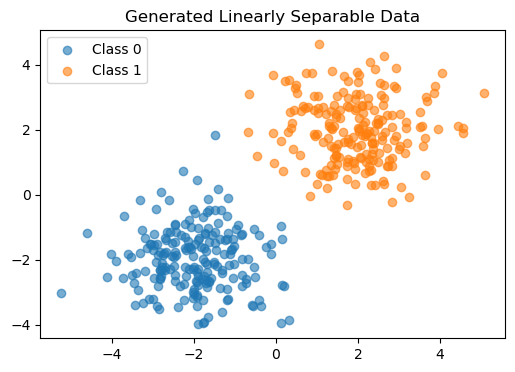


 2. 定义 sigmoid 与交叉熵损失
sigmoid([-1  0  1]) = [0.26894142 0.5        0.73105858]

 3. 梯度下降训练 
Epoch  100/1000 | Loss: 0.0324
Epoch  200/1000 | Loss: 0.0208
Epoch  300/1000 | Loss: 0.0163
Epoch  400/1000 | Loss: 0.0139
Epoch  500/1000 | Loss: 0.0122
Epoch  600/1000 | Loss: 0.0111
Epoch  700/1000 | Loss: 0.0102
Epoch  800/1000 | Loss: 0.0095
Epoch  900/1000 | Loss: 0.0090
Epoch 1000/1000 | Loss: 0.0085

训练完成，最终参数：w = [2.1698258 1.8662945], b = -0.004148600563620082


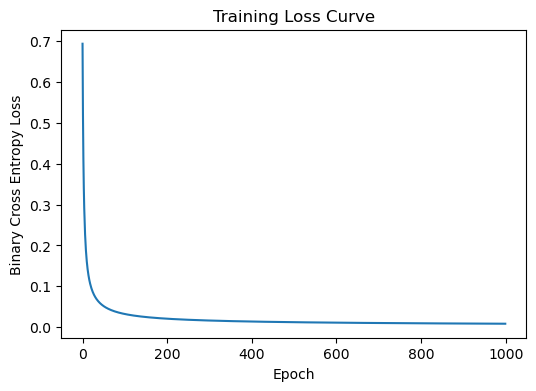


 4. 绘制决策边界与测试集评估 


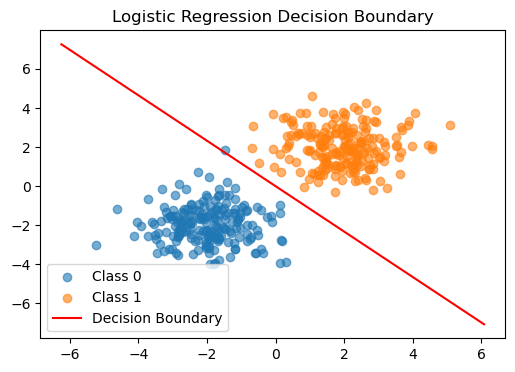

测试集准确率: 0.9900 (99.00%)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成两类线性可分数据
print("="*60)
print("1. 生成线性可分数据")
np.random.seed(42)
n_samples = 200

# 类别0：均值为(-2, -2)的二维正态分布
X0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
y0 = np.zeros(n_samples)

# 类别1：均值为(2, 2)的二维正态分布
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])
y1 = np.ones(n_samples)

# 合并数据
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))

print(f"数据总样本数: {X.shape[0]}, 特征维度: {X.shape[1]}")
print(f"类别0样本数: {len(y0)}, 类别1样本数: {len(y1)}")

# 可视化数据
plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], label='Class 0', alpha=0.6)
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1', alpha=0.6)
plt.title("Generated Linearly Separable Data")
plt.legend()
plt.show()


# 2. 定义 sigmoid 函数和二元交叉熵损失

print("\n 2. 定义 sigmoid 与交叉熵损失")
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    # 加小常数防止log(0)
    n = len(y_true)
    loss = (-1/n) * np.sum(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))
    return loss

# 测试函数
test_z = np.array([-1, 0, 1])
print(f"sigmoid({test_z}) = {sigmoid(test_z)}")

# ======================
# 3. 梯度下降学习参数 w, b
# ======================
print("\n 3. 梯度下降训练 ")
# 初始化参数
w = np.zeros(2)
b = 0
lr = 0.1
epochs = 1000
n = X.shape[0]

loss_history = []

for epoch in range(epochs):
    # 前向传播
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y)
    loss_history.append(loss)
    
    # 反向传播求梯度
    dw = (1/n) * np.dot(X.T, (y_pred - y))
    db = (1/n) * np.sum(y_pred - y)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    # 每100次打印损失
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d}/{epochs} | Loss: {loss:.4f}")

print(f"\n训练完成，最终参数：w = {w}, b = {b}")

# 绘制损失曲线
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.show()

# ======================
# 4. 绘制决策边界 + 测试集准确率
# ======================
print("\n 4. 绘制决策边界与测试集评估 ")
# 绘制决策边界
plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], label='Class 0', alpha=0.6)
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1', alpha=0.6)

# 决策边界：w1*x1 + w2*x2 + b = 0
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x_boundary = np.array([x_min, x_max])
y_boundary = (-w[0] * x_boundary - b) / w[1]
plt.plot(x_boundary, y_boundary, 'r-', label='Decision Boundary')

plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# 生成测试集（100个样本）
np.random.seed(123)
X0_test = np.random.randn(50, 2) + np.array([-2, -2])
X1_test = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack((X0_test, X1_test))
y_test = np.hstack((np.zeros(50), np.ones(50)))

# 预测
z_test = np.dot(X_test, w) + b
y_pred_test = (sigmoid(z_test) > 0.5).astype(int)

# 计算准确率
accuracy = np.mean(y_pred_test == y_test)
print(f"测试集准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("="*60)